# Punto 2
*ETAPA 1 - Análisis de la Tasa de Cambio Representativa del Mercado (TCRM)*

## Objetivo

Analizar el histórico de la TCRM suministrado por el cliente para:

- Encontrar la TCRM correspondiente a la fecha de expedición de la cédula.
- Verificar si el histórico presenta días sin información.
- Completar los datos faltantes mediante una función (si existen).
- Construir la serie diaria.
- Analizar el comportamiento histórico de la TCRM.

El modelo de pronóstico solicitado se desarrollará en el Notebook 02.

In [12]:
# ==========================================
# Librerías
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("default")

In [57]:
ruta = "../data/raw/Tasa_de_Cambio_Representativa_del__Mercado_-Historico.xlsx"

tcrm = pd.read_excel(ruta)

tcrm.head()

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
0,"2,850.98",COP,2002-10-09,2002-10-09
1,"2,854.04",COP,2002-10-10,2002-10-10
2,"2,870.63",COP,2002-10-11,2002-10-11
3,"2,861.16",COP,2002-10-12,2002-10-15
4,"2,852.99",COP,2002-10-16,2002-10-16


In [58]:
# ==========================================
# Información general del dataset
# ==========================================

tcrm.info()

display(tcrm.head())

display(tcrm.describe(include="all"))

<class 'pandas.DataFrame'>
RangeIndex: 7188 entries, 0 to 7187
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   VALOR          7188 non-null   str           
 1   UNIDAD         7188 non-null   str           
 2   VIGENCIADESDE  7188 non-null   datetime64[us]
 3   VIGENCIAHASTA  7188 non-null   datetime64[us]
dtypes: datetime64[us](2), str(2)
memory usage: 224.8 KB


,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
0,"2,850.98",COP,2002-10-09,2002-10-09
1,"2,854.04",COP,2002-10-10,2002-10-10
2,"2,870.63",COP,2002-10-11,2002-10-11
3,"2,861.16",COP,2002-10-12,2002-10-15
4,"2,852.99",COP,2002-10-16,2002-10-16


,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
count,7188,7188,7188,7188
unique,7001,1,NaN,NaN
top,"1,797.68",COP,NaN,NaN
freq,4,7188,NaN,NaN
mean,NaN,NaN,2006-09-21 10:19:25.943238,2006-09-21 22:46:04.607679
min,NaN,NaN,1991-12-02 00:00:00,1991-12-02 00:00:00
25%,NaN,NaN,1999-03-12 18:00:00,1999-03-14 06:00:00
50%,NaN,NaN,2006-08-23 12:00:00,2006-08-23 12:00:00
75%,NaN,NaN,2014-03-20 06:00:00,2014-03-20 06:00:00
max,NaN,NaN,2021-10-16 00:00:00,2021-10-19 00:00:00


In [59]:
# ==========================================
# Normalización de nombres
# ==========================================

tcrm.columns = (
    tcrm.columns
    .str.strip()
    .str.lower()
)

tcrm.columns

Index(['valor', 'unidad', 'vigenciadesde', 'vigenciahasta'], dtype='str')

In [60]:
# ==========================================
# Conversión de formatos
# ==========================================

tcrm["vigenciadesde"] = pd.to_datetime(
    tcrm["vigenciadesde"],
    dayfirst=True
)

tcrm["vigenciahasta"] = pd.to_datetime(
    tcrm["vigenciahasta"],
    dayfirst=True
)

tcrm["valor"] = (
    tcrm["valor"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

tcrm.info()

<class 'pandas.DataFrame'>
RangeIndex: 7188 entries, 0 to 7187
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   valor          7188 non-null   float64       
 1   unidad         7188 non-null   str           
 2   vigenciadesde  7188 non-null   datetime64[us]
 3   vigenciahasta  7188 non-null   datetime64[us]
dtypes: datetime64[us](2), float64(1), str(1)
memory usage: 224.8 KB


In [61]:
# ==========================================
# Valores faltantes
# ==========================================

display(tcrm.isna().sum())

print()

print("Registros:", len(tcrm))

valor            0
unidad           0
vigenciadesde    0
vigenciahasta    0
dtype: int64


Registros: 7188


*Punto A* 
# TCRM para la fecha de expedición de la cédula

El cliente solicita conocer la Tasa Representativa del Mercado (TCRM) correspondiente a la fecha de expedición de la cédula.

Como el archivo histórico almacena la información mediante rangos de vigencia (VIGENCIADESDE - VIGENCIAHASTA), la búsqueda se realiza verificando que la fecha consultada se encuentre dentro del período de vigencia de cada registro.

Encuentre la TCRM para la fecha de la expedición de su propia cédula

In [62]:
fecha_cedula = pd.Timestamp("2019-10-07")

In [63]:
tcrm_cedula = tcrm[
    (tcrm["vigenciadesde"] <= fecha_cedula) &
    (tcrm["vigenciahasta"] >= fecha_cedula)
]

tcrm_cedula

,valor,unidad,vigenciadesde,vigenciahasta
4049,3430.28,COP,2019-10-05,2019-10-07


In [64]:
valor_tcrm = tcrm_cedula.iloc[0]["valor"]

print(f"TCRM para el {fecha_cedula.date()}: ${valor_tcrm:,.2f}")

TCRM para el 2019-10-07: $3,430.28


In [65]:
print(f"""
Interpretación

La fecha de expedición consultada fue: {fecha_cedula.date()}.

La TCRM vigente para esa fecha fue de ${valor_tcrm:,.2f} COP por dólar.

El valor corresponde al registro cuya vigencia comprendía el periodo entre
{tcrm_cedula.iloc[0]['vigenciadesde'].date()} y
{tcrm_cedula.iloc[0]['vigenciahasta'].date()}.
""")


Interpretación

La fecha de expedición consultada fue: 2019-10-07.

La TCRM vigente para esa fecha fue de $3,430.28 COP por dólar.

El valor corresponde al registro cuya vigencia comprendía el periodo entre
2019-10-05 y
2019-10-07.



*Punto B*

¿Están completos los datos?,¿Cuántos días no se transaron?, cree una función para llenar los datos faltantes

In [66]:
# ==========================================
# Construcción del histórico diario
# ==========================================

def expandir_tcrm(df):

    registros = []

    for _, fila in df.iterrows():

        fechas = pd.date_range(
            fila["vigenciadesde"],
            fila["vigenciahasta"],
            freq="D"
        )

        for fecha in fechas:

            registros.append({

                "fecha": fecha,
                "valor": fila["valor"]

            })

    return pd.DataFrame(registros)

In [67]:
historico = expandir_tcrm(tcrm)

historico.head()

,fecha,valor
0,2002-10-09,2850.98
1,2002-10-10,2854.04
2,2002-10-11,2870.63
3,2002-10-12,2861.16
4,2002-10-13,2861.16


In [68]:
print("Filas antes:", len(historico))

print("Duplicados:", historico.duplicated("fecha").sum())

Filas antes: 10915
Duplicados: 0


In [69]:
historico = historico.drop_duplicates("fecha")

In [70]:
historico = historico.sort_values("fecha")

historico.reset_index(drop=True, inplace=True)

In [71]:
rango_fechas = pd.date_range(

    historico["fecha"].min(),
    historico["fecha"].max(),
    freq="D"

)

In [72]:
faltantes = rango_fechas.difference(historico["fecha"])

print("Días sin información:", len(faltantes))

Días sin información: 0


In [73]:
faltantes[:10]

DatetimeIndex([], dtype='datetime64[us]', freq='D')

In [74]:
if len(faltantes) == 0:

    print(
        "El histórico contiene información para todos los días."
    )

else:

    print(
        f"Se encontraron {len(faltantes)} días sin registro."
    )

El histórico contiene información para todos los días.


In [75]:
# ==========================================
# Función para completar el histórico
# ==========================================

def completar_tcrm(df):

    calendario = pd.DataFrame({

        "fecha": pd.date_range(

            df["fecha"].min(),
            df["fecha"].max(),
            freq="D"

        )

    })

    calendario = calendario.merge(

        df,

        how="left",

        on="fecha"

    )

    calendario["valor"] = calendario["valor"].ffill()

    return calendario

In [76]:
historico = completar_tcrm(historico)

In [77]:
historico.isna().sum()

fecha    0
valor    0
dtype: int64

# Interpretación

• El archivo original almacena la TCRM mediante rangos de vigencia y no como un registro independiente para cada día.

• Para validar la integridad de la información se expandió cada rango de vigencia hasta obtener una serie diaria.

• Posteriormente se comparó dicha serie con un calendario continuo comprendido entre la fecha mínima y máxima del histórico.

Resultado:

✔ No se encontraron días faltantes.

✔ Todos los días del periodo cuentan con una TCRM válida.

Por esta razón no fue necesario imputar valores adicionales.

No obstante, se desarrolló una función de completado mediante Forward Fill para garantizar que el procedimiento pueda reutilizarse si en futuros históricos aparecen fechas sin información.

*Punto C*

Grafique la TCMR contra el tiempo y haga un análisis de la curva observada.

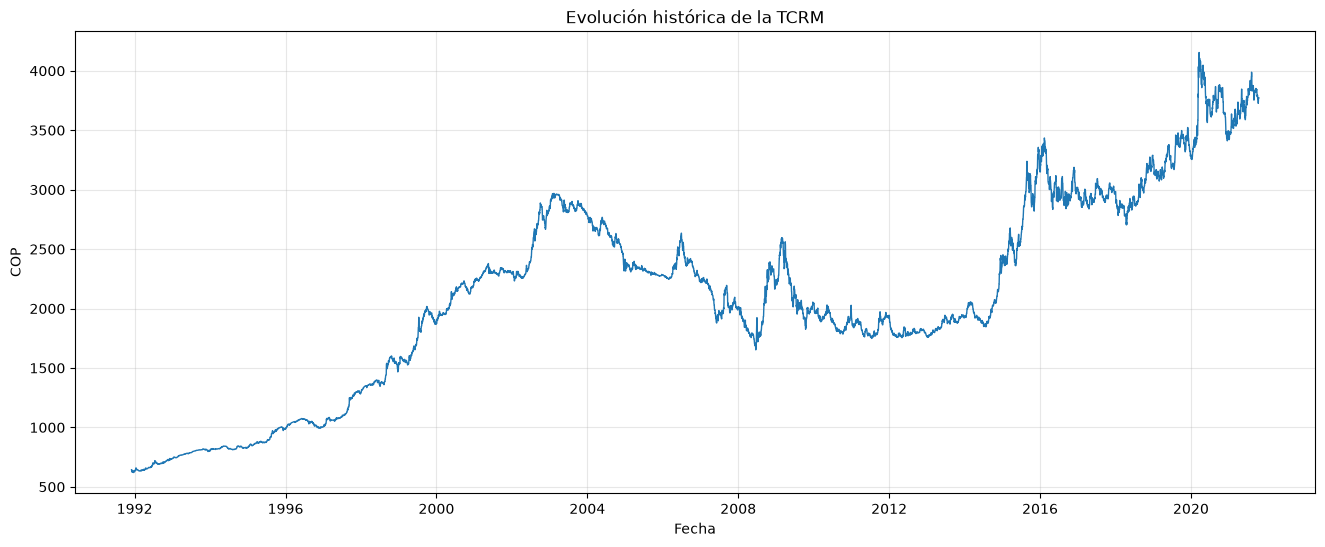

In [78]:
# ==========================================
# Evolución histórica de la TCRM
# ==========================================

plt.figure(figsize=(16,6))

plt.plot(

    historico["fecha"],
    historico["valor"],
    linewidth=1

)

plt.title("Evolución histórica de la TCRM")

plt.xlabel("Fecha")

plt.ylabel("COP")

plt.grid(alpha=0.3)

plt.show()

## c. Análisis - Evolución histórica de la TCRM

• La serie presenta una tendencia creciente en el largo plazo.
  La TCRM pasa de valores cercanos a $600 COP/USD a principios de los
  años 90 hasta niveles superiores a $3.800 COP/USD hacia el final
  del histórico.

• Aunque existe una tendencia general al alza, el comportamiento no es
  lineal. Se observan periodos de alta volatilidad donde la tasa cambia
  rápidamente en pocos meses.

• Entre 2002 y 2004 se observa un incremento importante de la TCRM,
  seguido por una etapa de corrección entre 2004 y 2007.

• Durante 2008 y 2009 la serie presenta uno de los movimientos más
  bruscos del histórico. Inicialmente se observa una caída significativa
  de la TCRM y posteriormente una recuperación acelerada, reflejando un
  periodo de alta incertidumbre en el mercado cambiario.

• Entre 2010 y 2014 la tasa mantiene un comportamiento relativamente
  estable, oscilando alrededor de los $1.800 - $2.000 COP/USD con una
  volatilidad moderada.

• A partir de 2015 comienza un nuevo ciclo de crecimiento donde la TCRM
  supera los $3.000 COP/USD y posteriormente continúa incrementándose
  hasta alcanzar máximos superiores a $4.000 COP/USD.

• No se observan patrones estacionales claros (mensuales o anuales).
  La serie está dominada principalmente por tendencias de largo plazo y
  cambios abruptos propios del comportamiento del mercado cambiario.

Conclusión:

La TCRM corresponde a una serie temporal no estacionaria, con tendencia
de largo plazo y periodos de alta volatilidad. Debido a estas
características resulta apropiado utilizar un modelo de pronóstico que
considere la dependencia temporal de los datos, como los modelos de
forecast que se desarrollan en el siguiente notebook.

In [79]:
# ==========================================
# Exportar histórico limpio
# ==========================================

from pathlib import Path

# Crear carpeta processed si no existe
Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

# Exportar histórico diario limpio
historico.to_excel(
    "../data/processed/tcrm_historico.xlsx",
    index=False
)

print("Histórico exportado correctamente.")

Histórico exportado correctamente.
